# 11 — NN5 Weekly Forecasting Experiment

This notebook runs the full benchmark experiment for the `nn5_weekly` dataset from the Time Series PILE.

Dataset details:

- Domain: Retail
- Frequency: Weekly
- Short horizon: 4
- Long horizon: 8
- Horizon strategy: Metadata

The notebook evaluates traditional forecasting models and time series foundation models under baseline and tuned/configured settings.

Models evaluated:

Traditional models:
- Naive
- Seasonal Naive
- ARIMA
- Prophet
- LSTM

Foundation models:
- TimesFM
- Tiny Time Mixer (TTM)
- Uni2TS

Metrics recorded:

- MAE
- RMSE
- sMAPE
- fit time
- inference time
- total runtime
- peak memory usage

Note: TTM adaptation experiments for this dataset are documented separately in `12_ttm_adaptation_nn5_weekly.ipynb`.

## 1. Setup

Add the project root to the Python path and import the required libraries.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root:", project_root)

Project root: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from src.data.dataset_loader import load_monash_dataset
from src.experiments.run_model_experiment import run_model_experiment

Importing plotly failed. Interactive plots will not work.


## 2. Experiment configuration

Define the dataset key, model list, and output directories for this experiment.

The experiments are run on all available series for the selected dataset.

In [3]:
DATASET_KEY = "nn5_weekly"

MODELS = [
    "naive",
    "seasonal_naive",
    "arima",
    "prophet",
    "lstm",
    "timesfm",
    "ttm",
    "uni2ts",
]

OUTPUT_DIR = project_root / "results" / "raw_runs"
AGGREGATED_DIR = project_root / "results" / "aggregated"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
AGGREGATED_DIR.mkdir(parents=True, exist_ok=True)

## 3. Load dataset

Load the selected dataset using the shared Monash dataset loader.

The returned bundle contains dataset metadata, parsed records, long-format data, and train-test split information. The default resolved horizon is used to define short- and long-horizon forecasting tasks.

In [4]:
bundle = load_monash_dataset(DATASET_KEY)

DEFAULT_HORIZON = int(bundle["resolved_horizon"])

HORIZON_CONFIG = {
    "short": max(1, DEFAULT_HORIZON // 2),
    "long": DEFAULT_HORIZON,
}

dataset_info = {
    "dataset_key": bundle["dataset_key"],
    "domain": bundle["domain"],
    "frequency": bundle["normalized_frequency"],
    "default_horizon": bundle["resolved_horizon"],
    "horizon_strategy": bundle["horizon_strategy"],
    "short_horizon": HORIZON_CONFIG["short"],
    "long_horizon": HORIZON_CONFIG["long"],
    "num_series": len(bundle["records_df"]),
    "num_long_rows": len(bundle["long_df"]),
}

dataset_info

{'dataset_key': 'nn5_weekly',
 'domain': 'retail',
 'frequency': 'weekly',
 'default_horizon': 8,
 'horizon_strategy': 'metadata',
 'short_horizon': 4,
 'long_horizon': 8,
 'num_series': 111,
 'num_long_rows': 12543}

## 4. Preview sample series

Plot one sample time series from the dataset to visually inspect the observed retail demand pattern before running benchmark experiments.

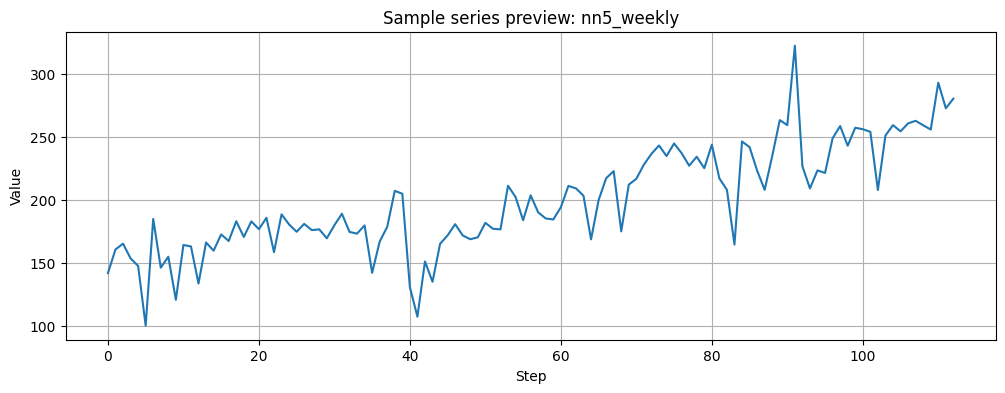

In [5]:
records_df = bundle["records_df"]
first_series = records_df.iloc[0]
values = first_series["series_values"][:500]

plt.figure(figsize=(12, 4))
plt.plot(values)
plt.title(f"Sample series preview: {DATASET_KEY}")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## 5. Define baseline model parameters

Define optional model-specific baseline parameters.

For `nn5_weekly`, the final baseline run uses default settings for all models. TTM adaptation is handled separately in `12_ttm_adaptation_nn5_weekly.ipynb`.

In [ ]:
MODEL_PARAMS_BY_MODEL = {}

MODEL_PARAMS_BY_MODEL

## 6. Run baseline experiments

Run all selected models under baseline/default settings for both short and long forecasting horizons.

The experiment is run on all available series in the selected dataset.

In [7]:
run_outputs = []

for horizon_type, horizon in HORIZON_CONFIG.items():
    print(f"\n==============================")
    print(f"Running horizon: {horizon_type} | h={horizon}")
    print(f"==============================")

    for model_name in MODELS:
        print(f"\nRunning model: {model_name}")

        model_params = MODEL_PARAMS_BY_MODEL.get(model_name, {})

        result_df = run_model_experiment(
            dataset_key=DATASET_KEY,
            model_name=model_name,
            horizon=horizon,
            horizon_type=horizon_type,
            experiment_type="baseline",
            output_dir=OUTPUT_DIR,
            model_params=model_params,
            series_limit=None,
            save_results=True,
        )

        run_outputs.append(result_df)

print("All runs completed.")


Running horizon: short | h=4

Running model: naive
Saved: results/raw_runs/retail/nn5_weekly/naive_short_h4_baseline.csv

Running model: seasonal_naive
Saved: results/raw_runs/retail/nn5_weekly/seasonal_naive_short_h4_baseline.csv

Running model: arima
Saved: results/raw_runs/retail/nn5_weekly/arima_short_h4_baseline.csv

Running model: prophet


INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run p

Saved: results/raw_runs/retail/nn5_weekly/prophet_short_h4_baseline.csv

Running model: lstm
Saved: results/raw_runs/retail/nn5_weekly/lstm_short_h4_baseline.csv

Running model: timesfm


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 19807.81it/s]
INFO:p-26367:t-8713740480:timesfm_2p5_torch.py:_from_pretrained:Loading checkpoint from local directory: /Users/kunalgurung/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3
INFO:p-26367:t-8713740480:timesfm_2p5_torch.py:_from_pretrained:Loading checkpoint from: /Users/kunalgurung/.cache/huggingface/hub/models--google--timesfm-2.5-200m-pytorch/snapshots/1d952420fba87f3c6dee4f240de0f1a0fbc790e3/model.safetensors


Compiling model...
Saved: results/raw_runs/retail/nn5_weekly/timesfm_short_h4_baseline.csv

Running model: ttm


...

Saved: results/raw_runs/retail/nn5_weekly/ttm_short_h4_baseline.csv

Running model: uni2ts
Saved: results/raw_runs/retail/nn5_weekly/uni2ts_short_h4_baseline.csv

Running horizon: long | h=8

Running model: naive
Saved: results/raw_runs/retail/nn5_weekly/naive_long_h8_baseline.csv

Running model: seasonal_naive
Saved: results/raw_runs/retail/nn5_weekly/seasonal_naive_long_h8_baseline.csv

Running model: arima
Saved: results/raw_runs/retail/nn5_weekly/arima_long_h8_baseline.csv

Running model: prophet


INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:forecaster.py:parse_seasonality_args:Disabling yearly seasonality. Run p

Saved: results/raw_runs/retail/nn5_weekly/prophet_long_h8_baseline.csv

Running model: lstm
Saved: results/raw_runs/retail/nn5_weekly/lstm_long_h8_baseline.csv

Running model: timesfm
Saved: results/raw_runs/retail/nn5_weekly/timesfm_long_h8_baseline.csv

Running model: ttm


INFO:p-26367:t-8713740480:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-26367:t-8713740480:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 90-30-ft-r2.1.
INFO:p-26367:t-8713740480:get_model.py:get_model:[TTM] context_length = 90, prediction_length = 30
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set 

Saved: results/raw_runs/retail/nn5_weekly/ttm_long_h8_baseline.csv

Running model: uni2ts
Saved: results/raw_runs/retail/nn5_weekly/uni2ts_long_h8_baseline.csv
All runs completed.


## 7. Combine baseline outputs

Concatenate all per-model baseline result DataFrames into one combined DataFrame for downstream analysis.

In [8]:
combined_df = pd.concat(run_outputs, ignore_index=True)

combined_df.head()

,series_id,dataset_key,domain,frequency,model,horizon,mae,rmse,smape,fit_time_seconds,...,use_continuous_quantile_head,force_flip_invariance,infer_is_positive,fix_quantile_crossing,model_path,normalized_frequency,prefer_longer_context,prefer_l1_loss,context_length,num_samples
0,T1,nn5_weekly,retail,weekly,naive,4,17.910289,21.067072,6.604236,2.861023e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T2,nn5_weekly,retail,weekly,naive,4,15.107710,15.479821,11.246742,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T3,nn5_weekly,retail,weekly,naive,4,14.728600,17.796923,8.060886,1.192093e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T4,nn5_weekly,retail,weekly,naive,4,22.732426,25.912973,14.977890,9.536743e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T5,nn5_weekly,retail,weekly,naive,4,21.070720,21.473611,12.921781,1.668930e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Inspect failed baseline runs

Check whether any model failed on specific series and inspect the associated error messages.

In [9]:
failed_df = combined_df[combined_df["status"] != "success"].copy()

failed_df[["dataset_key", "model", "horizon_type", "series_id", "error_message"]].head(20)

,dataset_key,model,horizon_type,series_id,error_message


## 9. Summarise baseline accuracy

Aggregate successful baseline runs by model and forecast horizon using MAE, RMSE, and sMAPE.

In [10]:
accuracy_summary_df = (
    combined_df[combined_df["status"] == "success"]
    .groupby(["dataset_key", "frequency", "model", "horizon_type", "horizon"], as_index=False)
    .agg(
        n_series=("series_id", "count"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "smape"])
    .reset_index(drop=True)
)

accuracy_summary_df

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape
0,nn5_weekly,weekly,timesfm,long,8,111,13.914181,17.346942,10.684763
1,nn5_weekly,weekly,prophet,long,8,111,15.373292,19.396225,11.840786
2,nn5_weekly,weekly,arima,long,8,111,16.167698,19.588209,12.813973
3,nn5_weekly,weekly,naive,long,8,111,16.708553,20.207279,13.267858
4,nn5_weekly,weekly,uni2ts,long,8,111,19.218265,23.139845,15.306523
5,nn5_weekly,weekly,seasonal_naive,long,8,111,21.702513,25.749531,16.370447
6,nn5_weekly,weekly,ttm,long,8,111,22.083139,25.312658,17.203020
7,nn5_weekly,weekly,lstm,long,8,111,135.083413,136.090430,196.276796
8,nn5_weekly,weekly,timesfm,short,4,111,14.814267,17.798888,11.365804
9,nn5_weekly,weekly,prophet,short,4,111,17.312416,21.113179,13.194650


## 10. Identify best baseline model per horizon

Select the model with the lowest sMAPE for each forecast horizon.

In [11]:
best_idx = accuracy_summary_df.groupby("horizon_type")["smape"].idxmin()

best_model_per_horizon_df = accuracy_summary_df.loc[
    best_idx,
    ["horizon_type", "horizon", "model", "smape", "mae", "rmse"]
].reset_index(drop=True)

best_model_per_horizon_df

,horizon_type,horizon,model,smape,mae,rmse
0,long,8,timesfm,10.684763,13.914181,17.346942
1,short,4,timesfm,11.365804,14.814267,17.798888


## 11. Summarise baseline runtime and memory

Aggregate average fit time, inference time, total per-series runtime, and peak memory usage for each model and horizon.

In [12]:
runtime_summary_df = (
    combined_df[combined_df["status"] == "success"]
    .groupby(["model", "horizon_type", "horizon"], as_index=False)
    .agg(
        avg_fit_time_seconds=("fit_time_seconds", "mean"),
        avg_inference_time_seconds=("inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("peak_memory_mb", "mean"),
        n_series=("series_id", "count"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

runtime_summary_df

,model,horizon_type,horizon,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,n_series
0,naive,long,8,6.443745e-07,0.000011,0.000014,0.153563,111
1,seasonal_naive,long,8,5.434225e-07,0.000033,0.000036,0.151405,111
2,arima,long,8,1.441251e-06,0.038403,0.038408,2.326182,111
3,timesfm,long,8,1.001788e-05,0.174317,0.174332,0.224334,111
4,prophet,long,8,1.183501e-05,0.189000,0.189017,4.677011,111
5,lstm,long,8,1.372518e-06,0.228542,0.228548,0.398717,111
6,ttm,long,8,1.406884e-06,0.432200,0.432207,2.299717,111
7,uni2ts,long,8,1.701149e-06,2.498017,2.498024,1.721075,111
8,naive,short,4,5.756413e-07,0.000009,0.000013,0.148593,111
9,seasonal_naive,short,4,6.787412e-07,0.000035,0.000039,0.152557,111


## 12. Compare baseline performance across horizons

Compare each model's sMAPE between short- and long-horizon settings to inspect horizon sensitivity.

In [13]:
horizon_comparison_df = accuracy_summary_df.pivot_table(
    index="model",
    columns="horizon_type",
    values="smape",
    aggfunc="mean",
).reset_index()

horizon_comparison_df["smape_change_long_minus_short"] = (
    horizon_comparison_df["long"] - horizon_comparison_df["short"]
)

horizon_comparison_df = horizon_comparison_df.sort_values("long").reset_index(drop=True)

horizon_comparison_df

horizon_type,model,long,short,smape_change_long_minus_short
0,timesfm,10.684763,11.365804,-0.681041
1,prophet,11.840786,13.194650,-1.353865
2,arima,12.813973,14.652446,-1.838474
3,naive,13.267858,15.033316,-1.765458
4,uni2ts,15.306523,13.419404,1.887119
5,seasonal_naive,16.370447,16.592029,-0.221583
6,ttm,17.203020,17.511651,-0.308631
7,lstm,196.276796,195.903449,0.373346


## 13. Compare model families

Group models into traditional and foundation model families for higher-level comparison.

In [14]:
def map_model_family(model_name: str) -> str:
    if model_name in {"naive", "seasonal_naive", "arima", "prophet", "lstm"}:
        return "traditional"
    if model_name in {"timesfm", "ttm", "uni2ts"}:
        return "foundation"
    return "other"


accuracy_summary_df["model_family"] = accuracy_summary_df["model"].apply(map_model_family)
runtime_summary_df["model_family"] = runtime_summary_df["model"].apply(map_model_family)

accuracy_summary_df.head()

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape,model_family
0,nn5_weekly,weekly,timesfm,long,8,111,13.914181,17.346942,10.684763,foundation
1,nn5_weekly,weekly,prophet,long,8,111,15.373292,19.396225,11.840786,traditional
2,nn5_weekly,weekly,arima,long,8,111,16.167698,19.588209,12.813973,traditional
3,nn5_weekly,weekly,naive,long,8,111,16.708553,20.207279,13.267858,traditional
4,nn5_weekly,weekly,uni2ts,long,8,111,19.218265,23.139845,15.306523,foundation


In [15]:
family_accuracy_df = (
    accuracy_summary_df
    .groupby(["model_family", "horizon_type"], as_index=False)
    .agg(
        avg_mae=("mae", "mean"),
        avg_rmse=("rmse", "mean"),
        avg_smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "avg_smape"])
    .reset_index(drop=True)
)

family_accuracy_df

,model_family,horizon_type,avg_mae,avg_rmse,avg_smape
0,foundation,long,18.405195,21.933148,14.398102
1,traditional,long,41.007094,44.206335,50.113972
2,foundation,short,18.259285,21.268633,14.098953
3,traditional,short,41.988893,44.889154,51.075178


In [16]:
family_runtime_df = (
    runtime_summary_df
    .groupby(["model_family", "horizon_type"], as_index=False)
    .agg(
        avg_fit_time_seconds=("avg_fit_time_seconds", "mean"),
        avg_inference_time_seconds=("avg_inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("avg_series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("avg_peak_memory_mb", "mean"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

family_runtime_df

,model_family,horizon_type,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb
0,traditional,long,0.000003,0.091198,0.091204,1.541376
1,foundation,long,0.000004,1.034845,1.034854,1.415042
2,traditional,short,0.000004,0.094351,0.094360,1.780846
3,foundation,short,0.000006,0.618310,0.618321,5.718624


## 14. Visualise baseline results

Plot baseline sMAPE by model and horizon, horizon sensitivity, and average inference time.

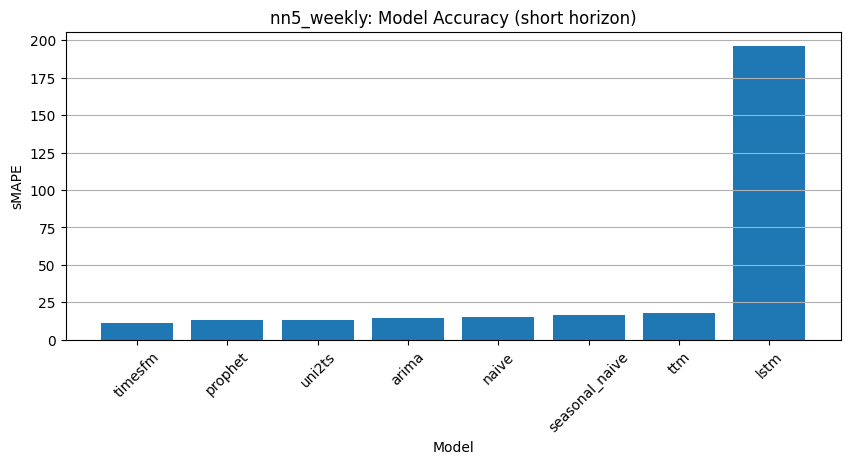

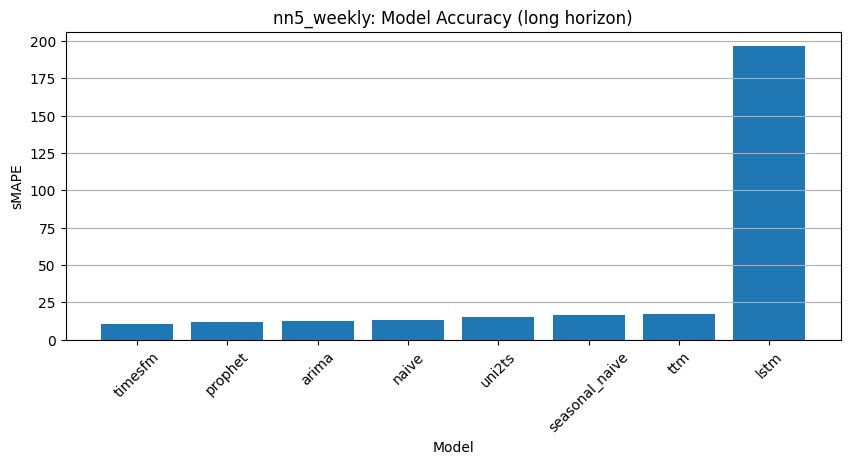

In [17]:
for horizon_type in HORIZON_CONFIG.keys():
    subset = accuracy_summary_df[accuracy_summary_df["horizon_type"] == horizon_type].copy()
    subset = subset.sort_values("smape")

    plt.figure(figsize=(10, 4))
    plt.bar(subset["model"], subset["smape"])
    plt.title(f"{DATASET_KEY}: Model Accuracy ({horizon_type} horizon)")
    plt.xlabel("Model")
    plt.ylabel("sMAPE")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

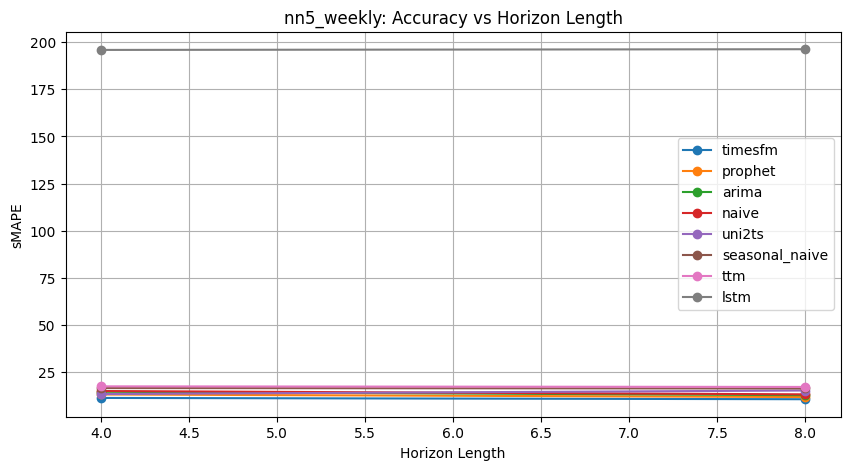

In [18]:
plot_df = accuracy_summary_df.copy()

plt.figure(figsize=(10, 5))

for model_name in plot_df["model"].unique():
    subset = plot_df[plot_df["model"] == model_name].sort_values("horizon")
    plt.plot(subset["horizon"], subset["smape"], marker="o", label=model_name)

plt.title(f"{DATASET_KEY}: Accuracy vs Horizon Length")
plt.xlabel("Horizon Length")
plt.ylabel("sMAPE")
plt.legend()
plt.grid(True)
plt.show()

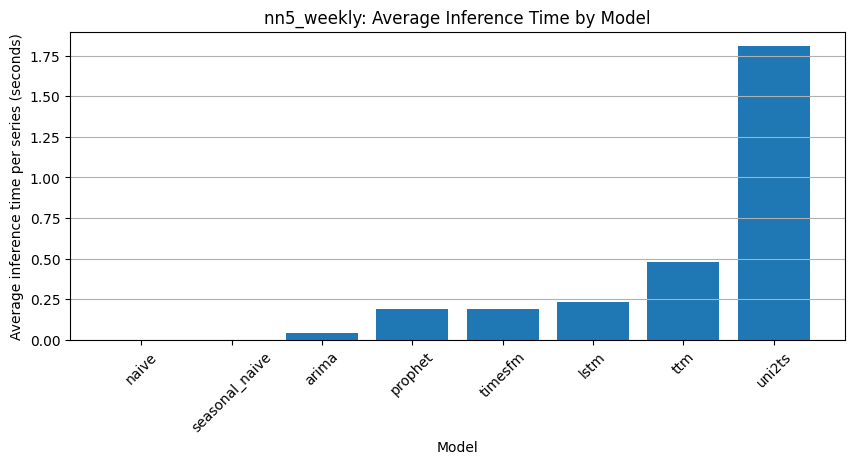

In [19]:
runtime_plot_df = (
    runtime_summary_df
    .groupby("model", as_index=False)["avg_inference_time_seconds"]
    .mean()
    .sort_values("avg_inference_time_seconds")
)

plt.figure(figsize=(10, 4))
plt.bar(runtime_plot_df["model"], runtime_plot_df["avg_inference_time_seconds"])
plt.title(f"{DATASET_KEY}: Average Inference Time by Model")
plt.xlabel("Model")
plt.ylabel("Average inference time per series (seconds)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

## 15. Save baseline summary outputs

Save aggregated baseline summaries for later cross-dataset analysis in the final analysis notebook.

In [20]:
accuracy_summary_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_accuracy_summary.csv",
    index=False,
)

best_model_per_horizon_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_best_model_per_horizon.csv",
    index=False,
)

runtime_summary_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_runtime_summary.csv",
    index=False,
)

horizon_comparison_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_horizon_comparison.csv",
    index=False,
)

family_accuracy_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_family_accuracy.csv",
    index=False,
)

family_runtime_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_family_runtime.csv",
    index=False,
)

print("Saved baseline summary outputs to:", AGGREGATED_DIR)

Saved outputs to: results/aggregated


## 16. Baseline findings checklist

Use the baseline summaries above to inspect:

- which model achieved the lowest sMAPE for the short horizon,
- which model achieved the lowest sMAPE for the long horizon,
- whether model ranking changed as horizon length increased,
- whether foundation models performed more consistently than traditional models,
- which models were fastest at inference,
- which models used the most memory.

The final cross-dataset interpretation is performed in `14_final_analysis.ipynb`.

## 17. Store baseline summaries for comparison

Keep baseline accuracy and runtime summaries in memory so they can be compared against tuned/configured runs.

In [32]:
baseline_accuracy_df = accuracy_summary_df.copy()
baseline_runtime_df = runtime_summary_df.copy()

print("Baseline saved.")

Baseline saved.


## 18. Define tuned/configured model parameters

Define dataset-specific tuned or configured parameters for the second experiment pass.

For this dataset:

- Prophet uses weekly seasonality with tuned prior settings.
- ARIMA uses a configured `(2, 1, 2)` order.
- LSTM uses a larger hidden size and longer training schedule.
- TimesFM uses default settings because this dataset did not require dataset-specific TimesFM overrides in the final experiments.
- TTM and Uni2TS use default settings in this notebook.
- Naive and Seasonal Naive use default deterministic settings.

TTM adaptation for this dataset is documented separately in `12_ttm_adaptation_nn5_weekly.ipynb`.

In [33]:
TUNED_MODEL_PARAMS = {
    "prophet": {
        "weekly_seasonality": True,
        "yearly_seasonality": False,
        "daily_seasonality": False,
        "changepoint_prior_scale": 0.03,
        "seasonality_prior_scale": 10.0,
        "seasonality_mode": "additive",
    },

    "arima": {
        "order": (2, 1, 2),
    },

    "lstm": {
        "hidden_size": 128,
        "num_layers": 2,
        "epochs": 50,
        "learning_rate": 0.0005,
    },

    # Keep fixed working TimesFM config.
    "timesfm": {
        "max_context": 128,
        "max_horizon": 256,
        "normalize_inputs": False,
        "use_continuous_quantile_head": True,
        "force_flip_invariance": False,
        "infer_is_positive": True,
        "fix_quantile_crossing": True,
    },

    "ttm": {},
    "uni2ts": {},

    "naive": {},
    "seasonal_naive": {},
}

## 19. Run tuned/configured experiments

Run the same models and horizons using the tuned/configured parameter dictionary.

In [34]:
run_outputs_tuned = []

for horizon_type, horizon in HORIZON_CONFIG.items():
    print(f"\n==============================")
    print(f"TUNED → horizon: {horizon_type} | h={horizon}")
    print(f"==============================")

    for model_name in MODELS:
        print(f"\nRunning tuned model: {model_name}")

        result_df = run_model_experiment(
            dataset_key=DATASET_KEY,
            model_name=model_name,
            horizon=horizon,
            horizon_type=horizon_type,
            experiment_type="tuned",
            output_dir=OUTPUT_DIR,
            model_params=TUNED_MODEL_PARAMS.get(model_name, {}),
            series_limit=None,
            save_results=True,
        )

        run_outputs_tuned.append(result_df)

print("All tuned runs completed.")


TUNED → horizon: short | h=4

Running tuned model: naive
Saved: results/raw_runs/retail/nn5_weekly/naive_short_h4_tuned.csv

Running tuned model: seasonal_naive
Saved: results/raw_runs/retail/nn5_weekly/seasonal_naive_short_h4_tuned.csv

Running tuned model: arima


/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-time

Saved: results/raw_runs/retail/nn5_weekly/arima_short_h4_tuned.csv

Running tuned model: prophet


INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model

Saved: results/raw_runs/retail/nn5_weekly/prophet_short_h4_tuned.csv

Running tuned model: lstm
Saved: results/raw_runs/retail/nn5_weekly/lstm_short_h4_tuned.csv

Running tuned model: timesfm
Saved: results/raw_runs/retail/nn5_weekly/timesfm_short_h4_tuned.csv

Running tuned model: ttm


...

Saved: results/raw_runs/retail/nn5_weekly/arima_long_h8_tuned.csv

Running tuned model: prophet


INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] done processing
INFO:p-26367:t-8713740480:model.py:_run_cmdstan:Chain [1] start processing
INFO:p-26367:t-8713740480:model

Saved: results/raw_runs/retail/nn5_weekly/prophet_long_h8_tuned.csv

Running tuned model: lstm
Saved: results/raw_runs/retail/nn5_weekly/lstm_long_h8_tuned.csv

Running tuned model: timesfm
Saved: results/raw_runs/retail/nn5_weekly/timesfm_long_h8_tuned.csv

Running tuned model: ttm


Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set to use cpu
Device set

Saved: results/raw_runs/retail/nn5_weekly/ttm_long_h8_tuned.csv

Running tuned model: uni2ts
Saved: results/raw_runs/retail/nn5_weekly/uni2ts_long_h8_tuned.csv
All tuned runs completed.


## 20. Combine tuned outputs

Concatenate all tuned/configured model outputs into one DataFrame.

In [35]:
combined_tuned_df = pd.concat(run_outputs_tuned, ignore_index=True)

combined_tuned_df.head()

,series_id,dataset_key,domain,frequency,model,horizon,mae,rmse,smape,fit_time_seconds,...,use_continuous_quantile_head,force_flip_invariance,infer_is_positive,fix_quantile_crossing,model_path,normalized_frequency,prefer_longer_context,prefer_l1_loss,context_length,num_samples
0,T1,nn5_weekly,retail,weekly,naive,4,17.910289,21.067072,6.604236,2.861023e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T2,nn5_weekly,retail,weekly,naive,4,15.107710,15.479821,11.246742,7.152557e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T3,nn5_weekly,retail,weekly,naive,4,14.728600,17.796923,8.060886,9.536743e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T4,nn5_weekly,retail,weekly,naive,4,22.732426,25.912973,14.977890,1.192093e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,T5,nn5_weekly,retail,weekly,naive,4,21.070720,21.473611,12.921781,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 21. Summarise tuned accuracy

Aggregate successful tuned/configured runs by model and forecast horizon using MAE, RMSE, and sMAPE.

In [36]:
accuracy_tuned_df = (
    combined_tuned_df[combined_tuned_df["status"] == "success"]
    .groupby(["dataset_key", "frequency", "model", "horizon_type", "horizon"], as_index=False)
    .agg(
        n_series=("series_id", "count"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        smape=("smape", "mean"),
    )
    .sort_values(["horizon_type", "smape"])
    .reset_index(drop=True)
)

accuracy_tuned_df

,dataset_key,frequency,model,horizon_type,horizon,n_series,mae,rmse,smape
0,nn5_weekly,weekly,timesfm,long,8,111,13.914181,17.346942,10.684763
1,nn5_weekly,weekly,prophet,long,8,111,15.642295,19.676103,12.037232
2,nn5_weekly,weekly,arima,long,8,111,15.684141,18.903194,12.226370
3,nn5_weekly,weekly,naive,long,8,111,16.708553,20.207279,13.267858
4,nn5_weekly,weekly,uni2ts,long,8,111,19.777763,23.794803,15.578601
5,nn5_weekly,weekly,seasonal_naive,long,8,111,21.702513,25.749531,16.370447
6,nn5_weekly,weekly,ttm,long,8,111,22.083139,25.312658,17.203020
7,nn5_weekly,weekly,lstm,long,8,111,123.869781,124.979039,163.277980
8,nn5_weekly,weekly,timesfm,short,4,111,14.814267,17.798888,11.365804
9,nn5_weekly,weekly,arima,short,4,111,16.373751,19.220921,12.612543


## 22. Compare baseline and tuned performance

Compare baseline and tuned/configured sMAPE for each model and horizon. Positive improvement means the tuned/configured run reduced sMAPE.

In [37]:
compare_df = baseline_accuracy_df.merge(
    accuracy_tuned_df,
    on=["model", "horizon_type"],
    suffixes=("_baseline", "_tuned"),
)

compare_df["smape_improvement"] = (
    compare_df["smape_baseline"] - compare_df["smape_tuned"]
)

compare_df = compare_df.sort_values(
    ["horizon_type", "smape_improvement"],
    ascending=[True, False]
)

compare_df

,dataset_key_baseline,frequency_baseline,model,horizon_type,horizon_baseline,n_series_baseline,mae_baseline,rmse_baseline,smape_baseline,model_family,dataset_key_tuned,frequency_tuned,horizon_tuned,n_series_tuned,mae_tuned,rmse_tuned,smape_tuned,smape_improvement
7,nn5_weekly,weekly,lstm,long,8,111,135.083413,136.090430,196.276796,traditional,nn5_weekly,weekly,8,111,123.869781,124.979039,163.277980,32.998816
2,nn5_weekly,weekly,arima,long,8,111,16.167698,19.588209,12.813973,traditional,nn5_weekly,weekly,8,111,15.684141,18.903194,12.226370,0.587603
0,nn5_weekly,weekly,timesfm,long,8,111,13.914181,17.346942,10.684763,foundation,nn5_weekly,weekly,8,111,13.914181,17.346942,10.684763,0.000000
3,nn5_weekly,weekly,naive,long,8,111,16.708553,20.207279,13.267858,traditional,nn5_weekly,weekly,8,111,16.708553,20.207279,13.267858,0.000000
5,nn5_weekly,weekly,seasonal_naive,long,8,111,21.702513,25.749531,16.370447,traditional,nn5_weekly,weekly,8,111,21.702513,25.749531,16.370447,0.000000
6,nn5_weekly,weekly,ttm,long,8,111,22.083139,25.312658,17.203020,foundation,nn5_weekly,weekly,8,111,22.083139,25.312658,17.203020,0.000000
1,nn5_weekly,weekly,prophet,long,8,111,15.373292,19.396225,11.840786,traditional,nn5_weekly,weekly,8,111,15.642295,19.676103,12.037232,-0.196446
4,nn5_weekly,weekly,uni2ts,long,8,111,19.218265,23.139845,15.306523,foundation,nn5_weekly,weekly,8,111,19.777763,23.794803,15.578601,-0.272077
15,nn5_weekly,weekly,lstm,short,4,111,133.787095,134.850429,195.903449,traditional,nn5_weekly,weekly,4,111,121.960666,123.132633,161.119769,34.783680
11,nn5_weekly,weekly,arima,short,4,111,18.183633,21.330045,14.652446,traditional,nn5_weekly,weekly,4,111,16.373751,19.220921,12.612543,2.039903


## 23. Summarise tuned runtime and memory

Aggregate runtime and memory usage for tuned/configured model runs.

In [38]:
runtime_tuned_df = (
    combined_tuned_df[combined_tuned_df["status"] == "success"]
    .groupby(["model", "horizon_type", "horizon"], as_index=False)
    .agg(
        avg_fit_time_seconds=("fit_time_seconds", "mean"),
        avg_inference_time_seconds=("inference_time_seconds", "mean"),
        avg_series_total_time_seconds=("series_total_time_seconds", "mean"),
        avg_peak_memory_mb=("peak_memory_mb", "mean"),
        n_series=("series_id", "count"),
    )
    .sort_values(["horizon_type", "avg_series_total_time_seconds"])
    .reset_index(drop=True)
)

runtime_tuned_df

,model,horizon_type,horizon,avg_fit_time_seconds,avg_inference_time_seconds,avg_series_total_time_seconds,avg_peak_memory_mb,n_series
0,naive,long,8,7.668057e-07,0.000011,0.000015,0.146323,111
1,seasonal_naive,long,8,7.002203e-07,0.000039,0.000043,0.151461,111
2,arima,long,8,1.690409e-06,0.178261,0.178269,3.547469,111
3,prophet,long,8,1.377888e-05,0.203659,0.203679,4.648044,111
4,timesfm,long,8,1.130663e-05,0.212496,0.212513,0.239709,111
5,ttm,long,8,1.718332e-06,0.489388,0.489395,0.893160,111
6,uni2ts,long,8,2.004005e-06,1.234383,1.234392,1.898361,111
7,lstm,long,8,1.735515e-06,3.209456,3.209463,0.294453,111
8,naive,short,4,5.627538e-07,0.000009,0.000013,16.647667,111
9,seasonal_naive,short,4,7.560661e-07,0.000040,0.000044,0.151945,111


## 24. Compare baseline and tuned runtime

Compare baseline and tuned/configured per-series runtime for each model and forecast horizon.

In [39]:
runtime_compare_df = baseline_runtime_df.merge(
    runtime_tuned_df,
    on=["model", "horizon_type", "horizon"],
    suffixes=("_baseline", "_tuned"),
)

runtime_compare_df["inference_time_change"] = (
    runtime_compare_df["avg_inference_time_seconds_tuned"]
    - runtime_compare_df["avg_inference_time_seconds_baseline"]
)

runtime_compare_df["memory_change_mb"] = (
    runtime_compare_df["avg_peak_memory_mb_tuned"]
    - runtime_compare_df["avg_peak_memory_mb_baseline"]
)

runtime_compare_df

,model,horizon_type,horizon,avg_fit_time_seconds_baseline,avg_inference_time_seconds_baseline,avg_series_total_time_seconds_baseline,avg_peak_memory_mb_baseline,n_series_baseline,model_family,avg_fit_time_seconds_tuned,avg_inference_time_seconds_tuned,avg_series_total_time_seconds_tuned,avg_peak_memory_mb_tuned,n_series_tuned,inference_time_change,memory_change_mb
0,naive,long,8,6.443745e-07,0.000011,0.000014,0.153563,111,traditional,7.668057e-07,0.000011,0.000015,0.146323,111,3.415185e-07,-0.007239
1,seasonal_naive,long,8,5.434225e-07,0.000033,0.000036,0.151405,111,traditional,7.002203e-07,0.000039,0.000043,0.151461,111,6.680016e-06,0.000055
2,arima,long,8,1.441251e-06,0.038403,0.038408,2.326182,111,traditional,1.690409e-06,0.178261,0.178269,3.547469,111,1.398588e-01,1.221287
3,timesfm,long,8,1.001788e-05,0.174317,0.174332,0.224334,111,foundation,1.130663e-05,0.212496,0.212513,0.239709,111,3.817959e-02,0.015375
4,prophet,long,8,1.183501e-05,0.189000,0.189017,4.677011,111,traditional,1.377888e-05,0.203659,0.203679,4.648044,111,1.465911e-02,-0.028967
5,lstm,long,8,1.372518e-06,0.228542,0.228548,0.398717,111,traditional,1.735515e-06,3.209456,3.209463,0.294453,111,2.980914e+00,-0.104264
6,ttm,long,8,1.406884e-06,0.432200,0.432207,2.299717,111,foundation,1.718332e-06,0.489388,0.489395,0.893160,111,5.718771e-02,-1.406557
7,uni2ts,long,8,1.701149e-06,2.498017,2.498024,1.721075,111,foundation,2.004005e-06,1.234383,1.234392,1.898361,111,-1.263634e+00,0.177286
8,naive,short,4,5.756413e-07,0.000009,0.000013,0.148593,111,traditional,5.627538e-07,0.000009,0.000013,16.647667,111,-2.577498e-08,16.499074
9,seasonal_naive,short,4,6.787412e-07,0.000035,0.000039,0.152557,111,traditional,7.560661e-07,0.000040,0.000044,0.151945,111,4.355972e-06,-0.000612


## 25. Save tuned runtime outputs

Save tuned/configured runtime summaries and baseline-vs-tuned runtime comparison outputs.

In [40]:
runtime_tuned_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_runtime_tuned.csv",
    index=False,
)

runtime_compare_df.to_csv(
    AGGREGATED_DIR / f"{DATASET_KEY}_runtime_compare_baseline_vs_tuned.csv",
    index=False,
)

print("Saved tuned runtime outputs to:", AGGREGATED_DIR)

## 26. Visualise tuning impact

Plot the average sMAPE improvement from baseline to tuned/configured runs. Positive values indicate improvement.

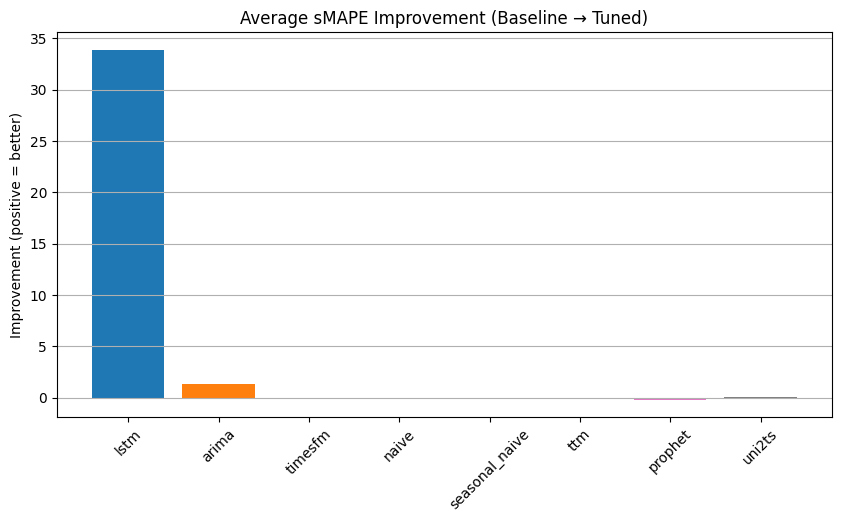

In [41]:
plt.figure(figsize=(10,5))

for model in compare_df["model"].unique():
    subset = compare_df[compare_df["model"] == model]
    plt.bar(model, subset["smape_improvement"].mean())

plt.title("Average sMAPE Improvement (Baseline → Tuned)")
plt.ylabel("Improvement (positive = better)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()